In [3]:
import importlib.util
spec = importlib.util.find_spec("vbfprocessor")
print(spec.origin)

import sys
sys.path.append('/uscms/home/azhou/nobackup/smeft/analysis/hbb-coffea/')
print(sys.path)

/uscms_data/d3/azhou/smeft/analysis/vbfprocessor.py
['/usr/local/lib', '/uscms_data/d3/azhou/smeft/analysis', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python311.zip', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11/lib-dynload', '', '/uscms_data/d3/azhou/mambaforge/envs/coffea-env/lib/python3.11/site-packages', '/uscms/home/azhou/nobackup/smeft/analysis/hbb-coffea/']


In [4]:
from coffea import util, processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, PFNanoAODSchema
from coffea.processor import Runner, FuturesExecutor, IterativeExecutor

import hist
import vbfprocessor
import awkward as ak
import uproot

import os
import time

import coffea
print(coffea.__version__)
import matplotlib.pyplot as plt
import numpy as np

import boostedhiggs.ewk_higgs_correction as ewk

importlib.reload(ewk)
print("vbfprocessor path:", vbfprocessor.__file__)
importlib.reload(vbfprocessor)

2025.10.2
vbfprocessor path: /uscms_data/d3/azhou/smeft/analysis/vbfprocessor.py


<module 'vbfprocessor' from '/uscms_data/d3/azhou/smeft/analysis/vbfprocessor.py'>

In [5]:
def run_samp(sample):

    fileset = {}
    fileset[sample] = all_filesets[sample]
    outfile = "coffea/"+sample+".coffea"

    #processor that computes stuff like higgs, pt, histograms, etc
    p = vbfprocessor.VBFProcessor(isMC=True, ewkHcorr=True, systematics=True)

    #sets how coffea processes events
    executor = FuturesExecutor(workers=4, status=True)

    #create runner instance - this loops over files in fileset and feeds events into processor
    runner = Runner(
        executor=executor,
        savemetrics=True,
        schema=NanoAODSchema,
        chunksize=50000,
    )

    #run job
    output, metrics = runner(
        fileset=fileset,
        processor_instance=p,
        treename="Events",
    )

    util.save(output, outfile)
    print("saved " + outfile)

In [ ]:
start0 = "/uscms/home/azhou/nobackup/smeft/jennet_files/start0_022526.root"
#old versions of start0 include: vbf_rw_start0_5000, start0_022126, start0_022526
start1 = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start1_5000.root"

cHW_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHW_HT2/VBFH_SMEFTsim_100.root"
cHWtil_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/VBF_SMEFTsim_topU3l_Direct_cHWtil_HT2/VBFH_SMEFTsim_101.root"

powheg_sample = "/uscms/home/jennetd/nobackup/hbb-prod-modes/eft/cmseft/generation/powheg-vbf/D59EF975-39CC-8B46-93D6-788FFA1EFE87.root"
powheg2_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/powheg.root"

all_filesets = {"start0": [start0],
          "start1": [start1],
               "cHW_sample": [cHW_sample],
               "cHWtil_sample": [cHWtil_sample],
               "powheg_sample": [powheg_sample],
               "powheg2_sample": [powheg2_sample]}

run_samp("start0")

In [12]:
def ratio_from_root(fname, htxs_branch="HTXS_stage1_2_fine_cat_pTjet25GeV", w_branch="genWeight"):
    '''
    Takes a root field and looks at the HTXS branch to
    returns bin1_yield, bin2_yield, ratio of bin2_yield to bin1_yield,
    nevents in b1, nevents in b2, ratio of nevents_1 to nevents_2
    '''
    t = uproot.open(fname)["Events"]
    htxs = t[htxs_branch].array()
    w = t[w_branch].array() if w_branch in t.keys() else ak.ones_like(htxs)

    bin1 = ak.sum(w[(htxs==221) | (htxs==222)])
    bin2 = ak.sum(w[(htxs==223) | (htxs==224)])

    # also unweighted counts:
    n1 = ak.sum(((htxs==221) | (htxs==222)))
    n2 = ak.sum(((htxs==223) | (htxs==224)))

    return float(bin1), float(bin2), float(bin2/bin1), int(n1), int(n2), float(n2/n1)

print('ratio for start0_022126:', ratio_from_root("/uscms/home/azhou/nobackup/smeft/jennet_files/start0_022126.root")) 
print('ratio for vbf_rw_start0_5000:', ratio_from_root("/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start0_5000.root"))


def htxs_spectrum(fname, branch="HTXS_stage1_2_fine_cat_pTjet25GeV"):
    t = uproot.open(fname)["Events"]
    array = ak.to_numpy(t[branch].array())
    u, c = np.unique(array, return_counts=True)
    return list(zip(u.tolist(), c.tolist()))

f_new = uproot.open("/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start0_5000.root")
t_new = f_new["Events"]

runs_new = f_new["Runs"]
b0 = [k for k in runs_new.keys() if k.startswith("LHESumw_EFTrwgt0000")][0]
print("Using Runs branch:", b0)
print("Runs sumw (new):", runs_new[b0].array(library="np").sum())

ratio for start0_022126: (74.11800384521484, 81.5298080444336, 1.100000023841858, 20, 22, 1.1)
ratio for vbf_rw_start0_5000: (160.03953552246094, 225.51022338867188, 1.4090907573699951, 46, 62, 1.3478260869565217)
Using Runs branch: LHESumw_EFTrwgt0000_cHbox_0.0_cHDD_0.0_cHW_0.0_cHB_0.0_cHWB_0.0_cuWRe_0.0_cuBRe_0.0_cdWRe_0.0_cdBRe_0.0_cHj1_0.0_cHj3_0.0_cHu_0.0_cHd_0.0_cHudRe_0.0_cHWtil_0.0_cHBtil_0.0_cHWBtil_0.0_cuWIm_0.0_cuBIm_0.0_cdWIm_0.0_cdBIm_0.0_cHudIm_0.0
Runs sumw (new): 1.0


storage: <class 'boost_histogram.storage.Weight'>
codes: [205, 209, 202, 213, 204, 223, 215, 211, 200, 203, 210, 212, 208, 201, 207, 219, 218, 221, 216, 214, 217, 206, 224, 220, 222]
Bin1 (221+222): 43.221195387112715
Bin2 (223+224): 49.27274963091707
ratio of bin2 to bin1 yields: 1.1400135787454122
bin1 and bin2 xsecs (fb): 23.262686637864014 26.519778645264438


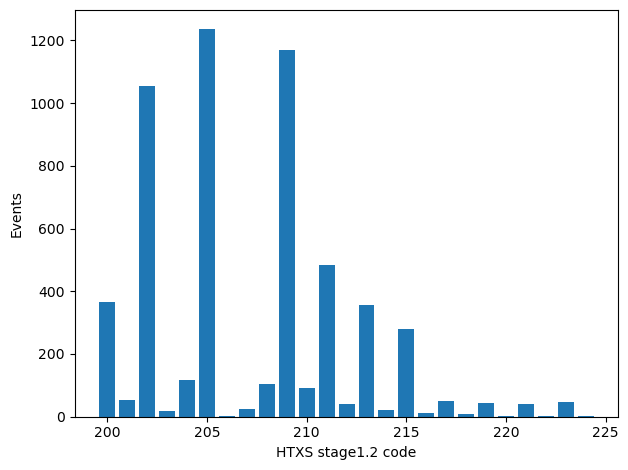

In [6]:
h_coffea = util.load("coffea/start0.coffea")
#print(start0_coffea.keys())
h_hpt = h_coffea["htxs"]

h = util.load("coffea/start0.coffea")["htxs"][{"wc": "SM"}]
print("storage:", h.storage_type)

sumw = h.values()
sumw2 = h.variances()

#--
h_axis = h.axes["htxs_stage2"]

values = h.values()

codes = [h_axis.bin(i) for i in range(h_axis.size)]
print("codes:", codes)

vbf_htxs_codes = [221, 222, 223, 224]
bin1_codes = [221,222]
bin2_codes = [223,224]

code_to_value = {code: values[i] for i, code in enumerate(codes)}

all_events = sum(values)

# missing1 = [c for c in bin1_codes if c not in code_to_value]
# missing2 = [c for c in bin2_codes if c not in code_to_value]
# print("Missing in bin1:", missing1)
# print("Missing in bin2:", missing2)

bin1_events = sum(code_to_value.get(c, 0.0) for c in bin1_codes)
bin2_events = sum(code_to_value.get(c, 0.0) for c in bin2_codes)

print(f"Bin1 yield (221+222): {bin1_events}")
print(f"Bin2 yield (223+224): {bin2_events}")
print("Ratio of bin2 to bin1 yields:", bin2_events/bin1_events)

bin1_frac = bin1_events / all_events
bin2_frac = bin2_events / all_events

sumw_all_noEW = h_coffea["sumw_all_noEW"].value

branching_ratio = 0.582
powheg_sigma = 2.2498
start0_MG_sigma = 3.594
xs1_fb = start0_MG_sigma * 1000.0 * (bin1_events / sumw_all_noEW)# / branching_ratio
xs2_fb = start0_MG_sigma * 1000.0 * (bin2_events / sumw_all_noEW)# / branching_ratio

print('bin1 and bin2 xsecs (fb):', xs1_fb, xs2_fb)

plt.bar(codes, values)
plt.xlabel("HTXS stage1.2 code")
plt.ylabel("Events")
plt.tight_layout()
plt.show()

Hist(
  Regular(200, 0, 1000, name='hpt', label='Higgs $p_{T}$ [GeV]'),
  StrCategory(['SM'], growth=True, name='wc', label='WC point'),
  storage=Weight()) # Sum: WeightedSum(value=3.55766e+06, variance=1.27404e+07) (WeightedSum(value=3.55909e+06, variance=1.27457e+07) with flow)
Hist(
  Regular(200, 0, 1000, name='hpt', label='Higgs $p_{T}$ [GeV]'),
  StrCategory(['SM'], growth=True, name='wc', label='WC point'),
  storage=Weight()) # Sum: WeightedSum(value=3.76478e+06, variance=1.42622e+07) (WeightedSum(value=3.7658e+06, variance=1.42662e+07) with flow)


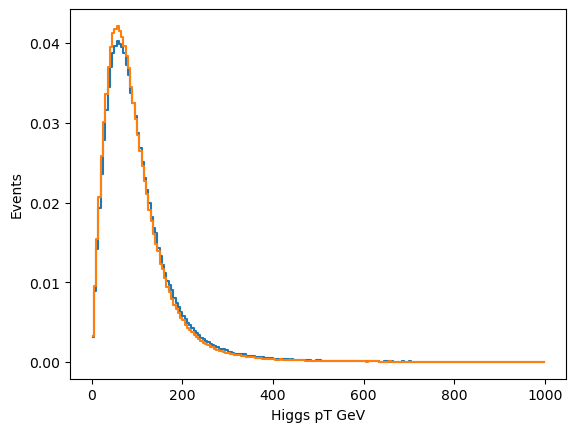

In [6]:
cHW_coffea_file = util.load("coffea/VBF_SMEFTsim_topU3l_Direct_cHW_HT2.coffea")
cHW_hpt = cHW_coffea_file["hpt"]
print(cHW_hpt)

cHW_hpt_sm = cHW_hpt[{"wc":"SM"}]

cHW_values, cHW_edges = cHW_hpt_sm.to_numpy()
cHW_centers = 0.5*(cHW_edges[1:]+cHW_edges[:-1])

cHWtil_coffea_file = util.load("coffea/VBF_SMEFTsim_topU3l_Direct_cHWtil_HT2.coffea")
cHWtil_hpt = cHWtil_coffea_file["hpt"]
print(cHWtil_hpt)

cHWtil_hpt_sm = cHWtil_hpt[{"wc": "SM"}]

cHWtil_values,  cHWtil_edges = cHWtil_hpt_sm.to_numpy()
cHWtil_centers = 0.5*(cHWtil_edges[1:]+cHWtil_edges[:-1])

cHW_norm = cHW_values / np.sum(cHW_values)
cHWtil_norm = cHWtil_values / np.sum(cHWtil_values)

plt.step(cHW_centers, cHW_norm, where="mid", label="cHW direct SM norm", color='tab:blue')
plt.step(cHWtil_centers, cHWtil_norm, where="mid", label="cHWtil direct SM norm", color='tab:orange')

plt.xlabel("Higgs pT GeV")
plt.ylabel("Events")
#plt.yscale('log')
plt.show()